In [56]:
%matplotlib inline

Here you can decide to use a pretrained model or train from scratch. 

In [57]:
pre_trained_flag = False # Set to False if you want to train the model


# Training a Classifier

This is it. You have seen how to define neural networks, compute loss and make
updates to the weights of the network.

Now you might be thinking,

## What about data?

Generally, when you have to deal with image, text, audio or video data,
you can use standard python packages that load data into a numpy array.
Then you can convert this array into a ``torch.*Tensor``.

-  For images, packages such as Pillow, OpenCV are useful
-  For audio, packages such as scipy and librosa
-  For text, either raw Python or Cython based loading, or NLTK and
   SpaCy are useful

Specifically for vision, we have created a package called
``torchvision``, that has data loaders for common datasets such as
ImageNet, CIFAR10, MNIST, etc. and data transformers for images, viz.,
``torchvision.datasets`` and ``torch.utils.data.DataLoader``.

This provides a huge convenience and avoids writing boilerplate code.

For this tutorial, we will use the CIFAR10 dataset.
It has the classes: ‘airplane’, ‘automobile’, ‘bird’, ‘cat’, ‘deer’,
‘dog’, ‘frog’, ‘horse’, ‘ship’, ‘truck’. The images in CIFAR-10 are of
size 3x32x32, i.e. 3-channel color images of 32x32 pixels in size.

.. figure:: /_static/img/cifar10.png
   :alt: cifar10

   cifar10


## Training an image classifier

We will do the following steps in order:

1. Load and normalize the CIFAR10 training and test datasets using
   ``torchvision``
2. Define a Convolutional Neural Network
3. Define a loss function
4. Train the network on the training data
5. Test the network on the test data

### 1. Load and normalize CIFAR10

Using ``torchvision``, it’s extremely easy to load CIFAR10.


In [58]:
import torch
import torchvision
import torchvision.transforms as transforms

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda:0































The output of torchvision datasets are PILImage images of range [0, 1].
We transform them to Tensors of normalized range [-1, 1].



<div class="alert alert-info"><h4>Note</h4><p>If running on Windows and you get a BrokenPipeError, try setting
    the num_worker of torch.utils.data.DataLoader() to 0.</p></div>



In [59]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(), # <-- Added random horizontal flip
    transforms.RandomRotation(10), # <-- Added random rotation up to 10 degrees
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 64

full_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=train_transform)

# Split into train and validation sets
train_size = int(0.85 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                        shuffle=False, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=test_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f'Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(testset)}')

Train size: 42500, Val size: 7500, Test size: 10000


Let us show some of the training images, for fun.



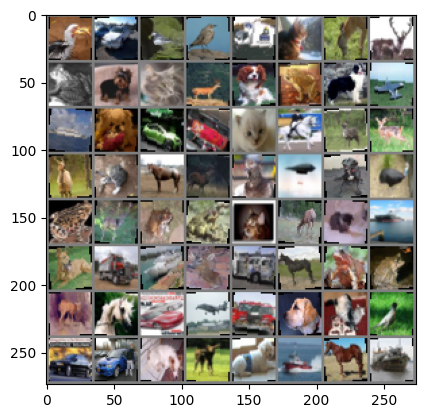

bird  car   bird  bird  truck cat   deer  deer  frog  dog   cat   deer  dog   frog  dog   plane ship  dog   car   truck cat   horse deer  deer  deer  cat   horse deer  bird  plane dog   bird  frog  deer  frog  frog  cat   deer  cat   ship  dog   truck ship  deer  truck horse frog  frog  deer  horse car   plane truck dog   cat   bird  car   car   dog   deer  dog   ship  horse ship 


In [60]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

### 2. Define a Convolutional Neural Network
Copy the neural network from the Neural Networks section before and modify it to
take 3-channel images (instead of 1-channel images as it was defined).



In [61]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()
net.to(device)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

### 3. Define a Loss function and optimizer
Let's use a Classification Cross-Entropy loss and SGD with momentum.



In [62]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4) # <-- Added L2 regularization with weight decay of 1e-4

### 4. Train the network

This is when things start to get interesting.
We simply have to loop over our data iterator, and feed the inputs to the
network and optimize.



In [63]:
if pre_trained_flag:

    !gdown --id 1NW2A_4yJi-ruAFkcM2ZwVu0paAxWoP1L

    PATH = './cifar_net.pth'

    net = Net()
    net.load_state_dict(torch.load(PATH, map_location=torch.device(device)))

In [64]:
if not pre_trained_flag:
    val_losses = []
    train_losses = []

    best_val_loss = float('inf')
    best_epoch = 0
    PATH = './cifar_net.pth'

    for epoch in range(100):

        # --- Training ---
        net.train()
        train_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(trainloader)
        train_losses.append(train_loss)

        # --- Validation ---
        net.eval()
        val_loss = 0.0
        with torch.no_grad():
            for data in valloader:
                images, labels = data[0].to(device), data[1].to(device)
                outputs = net(images)
                val_loss += criterion(outputs, labels).item()

        val_loss /= len(valloader)
        val_losses.append(val_loss)
        print(f'Epoch {epoch + 1} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}')

        # --- Early Stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            torch.save(net.state_dict(), PATH)
            print(f'  --> Best model saved (val loss: {best_val_loss:.4f})')

        elif epoch - (best_epoch - 1) >= 5:  # patience = 5
            print(f'Early stopping at epoch {epoch + 1}. Best epoch was {best_epoch}.')
            break

Epoch 1 - Train Loss: 2.3003 - Val Loss: 2.2954
  --> Best model saved (val loss: 2.2954)
Epoch 2 - Train Loss: 2.2546 - Val Loss: 2.1583
  --> Best model saved (val loss: 2.1583)
Epoch 3 - Train Loss: 2.0188 - Val Loss: 1.9419
  --> Best model saved (val loss: 1.9419)
Epoch 4 - Train Loss: 1.8414 - Val Loss: 1.7869
  --> Best model saved (val loss: 1.7869)
Epoch 5 - Train Loss: 1.7037 - Val Loss: 1.6918
  --> Best model saved (val loss: 1.6918)
Epoch 6 - Train Loss: 1.6137 - Val Loss: 1.5992
  --> Best model saved (val loss: 1.5992)
Epoch 7 - Train Loss: 1.5421 - Val Loss: 1.5492
  --> Best model saved (val loss: 1.5492)
Epoch 8 - Train Loss: 1.4912 - Val Loss: 1.4830
  --> Best model saved (val loss: 1.4830)
Epoch 9 - Train Loss: 1.4419 - Val Loss: 1.5158
Epoch 10 - Train Loss: 1.4054 - Val Loss: 1.4389
  --> Best model saved (val loss: 1.4389)
Epoch 11 - Train Loss: 1.3761 - Val Loss: 1.3969
  --> Best model saved (val loss: 1.3969)
Epoch 12 - Train Loss: 1.3447 - Val Loss: 1.3750
 

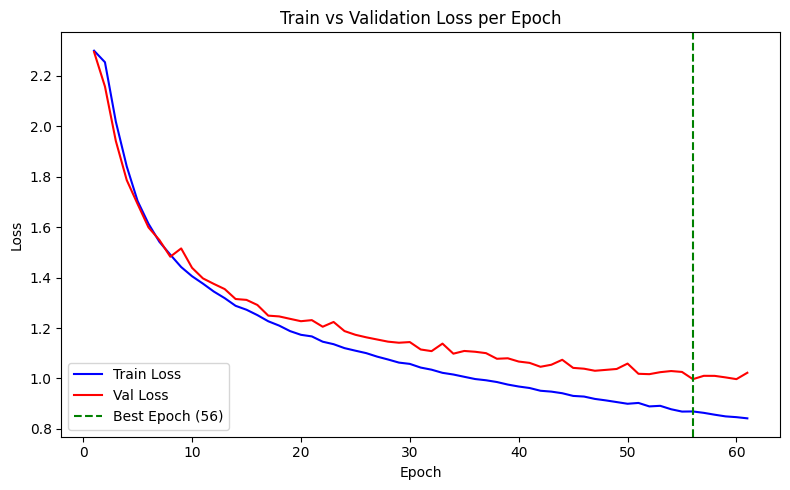

In [65]:
# --- PLOTTING ---
epochs = range(1, len(val_losses) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, 'b-', label='Train Loss')
plt.plot(epochs, val_losses, 'r-', label='Val Loss')
plt.axvline(x=best_epoch, color='g', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title('Train vs Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

Let's quickly save our trained model:



In [66]:

# Load the best model
net.load_state_dict(torch.load(PATH))
print(f'Finished Training. Best model from epoch {best_epoch} loaded.')



Finished Training. Best model from epoch 56 loaded.



### 5. Test the network on the test data

We have trained the network for 2 passes over the training dataset.
But we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network
outputs, and checking it against the ground-truth. If the prediction is
correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get familiar.



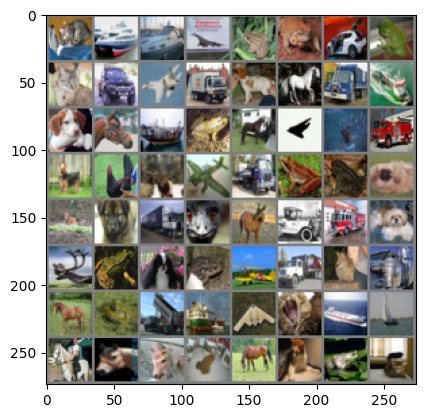

GroundTruth:  cat   ship  ship  plane


In [67]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

Next, let's load back in our saved model (note: saving and re-loading the model
wasn't necessary here, we only did it to illustrate how to do so):



In [68]:
net = Net()
net.load_state_dict(torch.load(PATH))

<All keys matched successfully>

Okay, now let us see what the neural network thinks these examples above are:



In [69]:
outputs = net(images)

The outputs are energies for the 10 classes.
The higher the energy for a class, the more the network
thinks that the image is of the particular class.
So, let's get the index of the highest energy:



In [70]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  cat   ship  ship  plane


The results seem pretty good.

Let us look at how the network performs on the whole dataset.



In [71]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 67 %


That looks way better than chance, which is 10% accuracy (randomly picking
a class out of 10 classes).
Seems like the network learnt something.

Hmmm, what are the classes that performed well, and the classes that did
not perform well:



In [72]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 68.8 %
Accuracy for class: car   is 83.5 %
Accuracy for class: bird  is 56.6 %
Accuracy for class: cat   is 46.4 %
Accuracy for class: deer  is 58.4 %
Accuracy for class: dog   is 55.9 %
Accuracy for class: frog  is 75.6 %
Accuracy for class: horse is 70.8 %
Accuracy for class: ship  is 82.1 %
Accuracy for class: truck is 72.7 %


In [73]:
#del dataiter